# TP01 — Reconnaissance de chiffres (MNIST) — **PyTorch**

**M2 DMIA — Deep Learning — Session 1**

Même objectif que la version Keras, mais en **PyTorch** : on écrit explicitement la **boucle d'entraînement** (forward → perte → backward → update). C'est plus verbeux, mais cela montre clairement ce qu'il se passe.

Pipeline : 1. Charger → 2. Prétraiter → 3. Modèle → 4. Perte + optimiseur → 5. Entraîner → 6. Évaluer → 7. Analyser.

> 💡 Sur Colab : Exécution → Modifier le type d'exécution → **GPU**.

## 0. Imports, device et reproductibilité

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch version :', torch.__version__)
print('Device :', device)

PyTorch version : 2.8.0+cpu
Device : cpu


## 1. Charger les données + 2. Prétraiter

`torchvision` télécharge MNIST. La transformation `ToTensor()` convertit l'image en tenseur et **normalise** automatiquement les pixels en [0, 1]. On charge les données par **mini-batches** via un `DataLoader`.

In [3]:
transform = transforms.ToTensor()  # -> tenseur, pixels dans [0, 1]

train_set = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_set  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)

print('Train :', len(train_set), '| Test :', len(test_set))

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.02MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 318kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.10MB/s]

Train : 60000 | Test : 10000


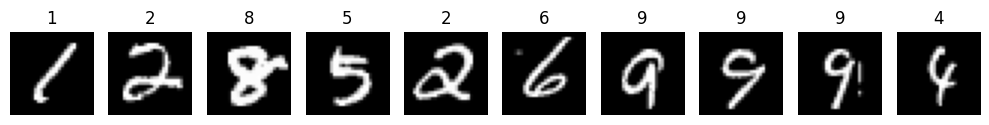

In [4]:
# Visualisons un batch
images, labels = next(iter(train_loader))
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(int(labels[i]))
    plt.axis('off')
plt.tight_layout(); plt.show()

## 3. Définir le modèle

Même architecture qu'en Keras : `784 → 128 → 64 → 10`, ReLU sur les couches cachées.

> ⚠️ En PyTorch, on ne met **pas** de softmax dans le modèle : la perte `CrossEntropyLoss` l'applique en interne (sur les *logits*).

In [5]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),          # 1x28x28 -> 784
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)      # logits (pas de softmax ici)
        )

    def forward(self, x):
        return self.net(x)

model = MLP().to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print('Nombre de parametres :', n_params)

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)
Nombre de parametres : 109386


## 4. Perte + optimiseur

In [6]:
criterion = nn.CrossEntropyLoss()                      # entropie croisee (logits)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## 5. Entraîner — la boucle explicite

C'est ici qu'on voit les **4 étapes** de la rétropropagation :
1. `pred = model(x)` → **forward**
2. `loss = criterion(pred, y)` → **perte**
3. `loss.backward()` → **backward** (calcul des gradients)
4. `optimizer.step()` → **mise à jour** des poids (puis `zero_grad()` pour repartir à zéro).

In [7]:
def evaluate(loader):
    """Retourne (perte moyenne, accuracy) sur un loader."""
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss_sum += criterion(pred, y).item() * x.size(0)
            correct  += (pred.argmax(1) == y).sum().item()
            total    += x.size(0)
    return loss_sum / total, correct / total

EPOCHS = 5
history = {'train_loss': [], 'test_loss': [], 'test_acc': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()      # 0. remettre les gradients a zero
        pred = model(x)            # 1. forward
        loss = criterion(pred, y)  # 2. perte
        loss.backward()            # 3. backward
        optimizer.step()           # 4. mise a jour
        running += loss.item() * x.size(0)

    train_loss = running / len(train_set)
    test_loss, test_acc = evaluate(test_loader)
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    print(f'Epoque {epoch}/{EPOCHS} | train_loss={train_loss:.4f} | test_loss={test_loss:.4f} | test_acc={test_acc:.4f}')

Epoque 1/5 | train_loss=0.4086 | test_loss=0.2058 | test_acc=0.9373
Epoque 2/5 | train_loss=0.1692 | test_loss=0.1368 | test_acc=0.9581
Epoque 3/5 | train_loss=0.1173 | test_loss=0.1128 | test_acc=0.9653
Epoque 4/5 | train_loss=0.0897 | test_loss=0.0936 | test_acc=0.9710
Epoque 5/5 | train_loss=0.0710 | test_loss=0.0826 | test_acc=0.9746


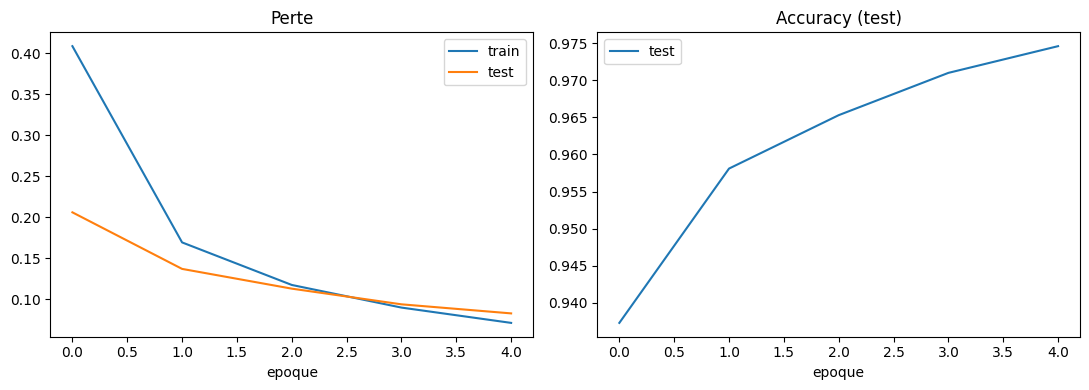

In [8]:
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='train')
plt.plot(history['test_loss'], label='test')
plt.title('Perte'); plt.xlabel('epoque'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['test_acc'], label='test')
plt.title('Accuracy (test)'); plt.xlabel('epoque'); plt.legend()
plt.tight_layout(); plt.show()

## 6. Évaluer

In [9]:
final_loss, final_acc = evaluate(test_loader)
print(f'Accuracy finale sur le test : {final_acc:.4f}  (perte : {final_loss:.4f})')

Accuracy finale sur le test : 0.9746  (perte : 0.0826)


## 7. Analyser : matrice de confusion

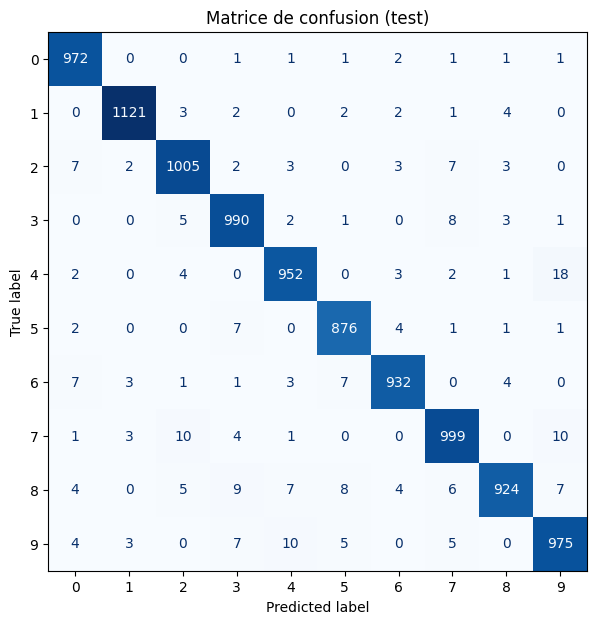

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        all_pred.append(model(x).argmax(1).cpu().numpy())
        all_true.append(y.numpy())
all_pred = np.concatenate(all_pred)
all_true = np.concatenate(all_true)

cm = confusion_matrix(all_true, all_pred)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matrice de confusion (test)')
plt.show()

## 8. À toi de jouer 

1. **Learning rate** : essaie `lr=1e-2` puis `lr=1e-4`. Que se passe-t-il ?
2. **Architecture** : ajoute une couche cachée ou augmente leur taille.
3. **SGD vs Adam** : remplace l'optimiseur par `torch.optim.SGD(model.parameters(), lr=0.1)`.
4. **Question** : compare le temps d'entraînement CPU vs GPU (si dispo).

> Compare aussi avec la version **Keras** : mêmes concepts, le code change, le résultat est similaire.

In [11]:
# Ton espace d'experimentation
# ...
